# Deterministic PVE to Cosine Reference and Overfitting Diagnostics

This notebook tests whether the ideal PVE value from the deterministic data generator can be converted into the same scale as the deterministic cosine-separation plots, then uses that reference to build simple overfitting diagnostics.

The main idea is:

```text
PVE = signal variance / total variance
cosine(clean signal, noisy signal) ~= sqrt(PVE)
```

That approximation needs the clean signal and noise to be independent and mean-zero. Because the actual plots use **true-pair separation** rather than plain cosine, this notebook also computes an empirical ideal cosine-separation reference with the exact same metric function used for the model results.


## 1. Imports

The path setup lets this notebook run from the repository root or from inside `experiment-notebooks/`.


In [11]:
from __future__ import annotations

from pathlib import Path
import inspect
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

GLOBAL_SEED = 123
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

P_DIM = 128
Q_DIM = 128

cwd = Path.cwd().resolve()
for candidate in [cwd, *cwd.parents]:
    if (candidate / "contrastive_encoders").exists():
        module_root = candidate
        break
else:
    raise RuntimeError("Could not find the contrastive_encoders package folder.")

if str(module_root) not in sys.path:
    sys.path.insert(0, str(module_root))

PLOT_DIR = module_root / "reports" / "report-plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print("DEVICE:", DEVICE)
print("module_root:", module_root)
print("plot output:", PLOT_DIR)


DEVICE: cpu
module_root: /Users/b4her/Desktop/git-repos/Remote/utssrp-cca-contrastive-encoders
plot output: /Users/b4her/Desktop/git-repos/Remote/utssrp-cca-contrastive-encoders/reports/report-plots


In [12]:
import importlib

import contrastive_encoders
from contrastive_encoders import data, experiments, metrics, plotting, training

for module in [data, metrics, training, experiments, plotting]:
    importlib.reload(module)

importlib.reload(contrastive_encoders)

from contrastive_encoders import (
    deterministic_dataset_snr,
    friendly_results_table,
    generate_deterministic_relation_dataset,
    make_first_experiment_configs,
    plot_metric_by_config,
    run_deterministic_relation_experiment,
)
from contrastive_encoders.metrics import alignment_gap, normalize_rows_np
from contrastive_encoders.plotting import REPORT_PALETTE, REFERENCE_LINE_COLOR


## 2. Function used for cosine separation

The deterministic bar plots use `test_pair_separation`. That value comes from `alignment_gap`: first the embedding rows are normalized, then the similarity matrix is computed as a dot product, and finally the plot uses:

```text
mean diagonal cosine - mean off-diagonal cosine
```

So the plot is not only the average true-pair cosine. It is true-pair cosine **relative to mismatched pairs**.


In [13]:
print(inspect.getsource(normalize_rows_np))
print(inspect.getsource(alignment_gap))


def normalize_rows_np(Z: np.ndarray) -> np.ndarray:
    return Z / np.maximum(np.linalg.norm(Z, axis=1, keepdims=True), 1e-12)

def alignment_gap(
    z_x: np.ndarray,
    z_y: np.ndarray,
) -> float:
    """Matched cosine similarity minus mismatched cosine similarity."""
    zx = normalize_rows_np(z_x)
    zy = normalize_rows_np(z_y)
    S = zx @ zy.T

    matched = np.diag(S).mean()
    if S.shape[0] <= 1:
        return float(matched)

    mismatched = (S.sum() - np.trace(S)) / (S.size - S.shape[0])
    return float(matched - mismatched)



## 3. Converting PVE to a cosine reference

For a clean signal vector `s` and noisy vector `y = s + epsilon`, assume:

```text
E[s] = 0
E[epsilon] = 0
s independent of epsilon
```

Then:

```text
cos(s, y) = <s, y> / (||s|| ||y||)
          ~= Var(s) / sqrt(Var(s) * Var(s + epsilon))
          = sqrt(Var(s) / Var(s + epsilon))
          = sqrt(PVE)
```

Because the plotted metric is a separation score, the closest converted reference is:

```text
ideal cosine separation = matched clean/noisy cosine - mismatched clean/noisy cosine
```

If mismatched pairs have expected cosine near zero, this is approximately `sqrt(PVE)`. To avoid relying only on that approximation, the notebook computes the empirical ideal separation from the generated deterministic test data.


In [14]:
def pve_to_ideal_cosine(pve: float) -> float:
    """Analytic zero-mean independent-noise approximation: cosine ~= sqrt(PVE)."""
    return float(np.sqrt(np.clip(pve, 0.0, 1.0)))


def clean_and_noisy_y_on_training_scale(dataset):
    """
    Put clean f(X) and noisy Y on the same coordinate scale used for training Y.

    The model trains on standardized Y. For the ideal reference, we compare the
    clean target and noisy observation after applying the training Y mean/scale.
    """
    y_mean = dataset.Y_train.mean(axis=0, keepdims=True)
    y_scale = dataset.Y_train.std(axis=0, ddof=1, keepdims=True)
    y_scale = np.where(y_scale > 1e-12, y_scale, 1.0)

    clean_y_test = (dataset.Z_y_test - y_mean) / y_scale
    noisy_y_test = (dataset.Y_test - y_mean) / y_scale
    return clean_y_test, noisy_y_test


def empirical_ideal_cosine_separation(dataset) -> float:
    """Use the exact same separation metric as the trained-model plots."""
    clean_y_test, noisy_y_test = clean_and_noisy_y_on_training_scale(dataset)
    return alignment_gap(clean_y_test, noisy_y_test)


## 4. Deterministic settings

These match the deterministic notebook, but use a denser SNR grid so the line plots show curves instead of three-point sketches. The cubic relation uses a larger raw X standard deviation so the cubic curve is evaluated on a wider range.


In [15]:
deterministic_configs = make_first_experiment_configs(epochs=300)

deterministic_relationships = ["linear", "cubic", "exponential", "signed_log"]
deterministic_x_std_by_relationship = {
    "linear": 1.0,
    "cubic": 5.0,
    "exponential": 1.0,
    "signed_log": 1.0,
}

# Dense grid for the SNR sweep and overfitting line plots.
deterministic_snr_values = [
    0.25,
    0.35,
    0.5,
    0.75,
    1.0,
    1.5,
    2.0,
    3.0,
    5.0,
    8.0,
    12.0,
    20.0,
]

# Keep the individual bar plots to representative points so the notebook does
# not generate too many near-duplicate figures.
deterministic_bar_snr_values = [0.25, 2.0, 20.0]


def snr_label(target_snr: float) -> str:
    if np.isclose(target_snr, 0.25):
        return "low SNR"
    if np.isclose(target_snr, 2.0):
        return "mid SNR"
    if np.isclose(target_snr, 20.0):
        return "very high SNR"
    return f"SNR={target_snr:g}"


## 5. Ideal reference table

The table compares:

- `ideal_pve`: the variance-explained value from SNR.
- `sqrt_ideal_pve`: the analytic cosine approximation.
- `ideal_cosine_separation`: the empirical reference in the same units as the deterministic separation plots.

The empirical value is the safest line to put on the deterministic cosine-separation plots because it uses the same `alignment_gap` function as the model metric.


In [16]:
reference_rows = []

for relationship_index, relationship in enumerate(deterministic_relationships):
    for snr_index, target_snr in enumerate(deterministic_snr_values):
        dataset_seed = GLOBAL_SEED + 1300 + 1000 * relationship_index + snr_index
        rng = np.random.default_rng(dataset_seed)
        dataset = generate_deterministic_relation_dataset(
            n_train=160,
            n_test=800,
            p=P_DIM,
            q=Q_DIM,
            relationship=relationship,
            target_snr=target_snr,
            rng=rng,
            x_std=deterministic_x_std_by_relationship[relationship],
        )
        snr_info = deterministic_dataset_snr(dataset)
        ideal_pve = snr_info["oracle_pve"]

        reference_rows.append(
            {
                "relationship": relationship,
                "x_std": deterministic_x_std_by_relationship[relationship],
                "target_snr": target_snr,
                "snr_level": snr_label(target_snr),
                "realized_snr": snr_info["realized_snr"],
                "ideal_pve": ideal_pve,
                "sqrt_ideal_pve": pve_to_ideal_cosine(ideal_pve),
                "ideal_cosine_separation": empirical_ideal_cosine_separation(dataset),
            }
        )

ideal_reference = pd.DataFrame(reference_rows)
display(ideal_reference.round(4))


,relationship,x_std,target_snr,snr_level,realized_snr,ideal_pve,sqrt_ideal_pve,ideal_cosine_separation
0,linear,1.0,0.25,low SNR,0.2498,0.1999,0.4471,0.4370
1,linear,1.0,0.35,SNR=0.35,0.3438,0.2558,0.5058,0.4989
2,linear,1.0,0.50,SNR=0.5,0.4982,0.3326,0.5767,0.5631
3,linear,1.0,0.75,SNR=0.75,0.7453,0.4270,0.6535,0.6468
4,linear,1.0,1.00,SNR=1,1.0040,0.5010,0.7078,0.6954
5,linear,1.0,1.50,SNR=1.5,1.4866,0.5978,0.7732,0.7647
6,linear,1.0,2.00,mid SNR,1.9934,0.6659,0.8160,0.8098
7,linear,1.0,3.00,SNR=3,3.0004,0.7500,0.8660,0.8589
8,linear,1.0,5.00,SNR=5,4.9701,0.8325,0.9124,0.9064
9,linear,1.0,8.00,SNR=8,8.0228,0.8892,0.9430,0.9354


## 6. Run deterministic model results

This runs only the deterministic experiments and then merges in the converted cosine reference values.


In [17]:
deterministic_results = run_deterministic_relation_experiment(
    configs=deterministic_configs,
    seed=GLOBAL_SEED + 1300,
    device=DEVICE,
    relationships=deterministic_relationships,
    x_std_by_relationship=deterministic_x_std_by_relationship,
    snr_values=deterministic_snr_values,
    n_train=160,
    n_test=800,
    p=P_DIM,
    q=Q_DIM,
)

deterministic_results["snr_level"] = deterministic_results["target_snr"].map(snr_label)

deterministic_results = deterministic_results.merge(
    ideal_reference[
        [
            "relationship",
            "target_snr",
            "ideal_pve",
            "sqrt_ideal_pve",
            "ideal_cosine_separation",
        ]
    ],
    on=["relationship", "target_snr"],
    how="left",
)

display(
    friendly_results_table(
        deterministic_results[
            [
                "setting",
                "relationship",
                "snr_level",
                "target_snr",
                "config",
                "train_pair_separation",
                "test_pair_separation",
                "shuffled_pair_separation",
                "ideal_cosine_separation",
                "sqrt_ideal_pve",
                "ideal_pve",
                "test_top5_pair_match_accuracy",
            ]
        ].round(4)
    )
)


,Dataset,Deterministic relation,SNR level,Target SNR,Model,Train true-pair separation,Test true-pair separation,Shuffled-pair check,ideal_cosine_separation,sqrt_ideal_pve,ideal_pve,Test top-5 retrieval accuracy
0,Deterministic linear,linear,low SNR,0.25,Linear encoder (alpha=0),0.6537,0.0997,0.0020,0.4370,0.4471,0.1999,0.0162
1,Deterministic linear,linear,low SNR,0.25,MLP nonlinear (alpha=0.01),0.6829,0.1343,0.0211,0.4370,0.4471,0.1999,0.0075
2,Deterministic linear,linear,low SNR,0.25,MLP nonlinear (alpha=0.10),0.6974,0.1163,0.0294,0.4370,0.4471,0.1999,0.0112
3,Deterministic linear,linear,low SNR,0.25,MLP nonlinear (alpha=1.00),0.9752,0.0361,-0.0109,0.4370,0.4471,0.1999,0.0038
4,Deterministic linear,linear,low SNR,0.25,L1-regularized nonlinear (alpha=0.10),0.7209,0.1461,-0.0011,0.4370,0.4471,0.1999,0.0088
...,...,...,...,...,...,...,...,...,...,...,...,...
283,Deterministic signed_log,signed_log,very high SNR,20.00,MLP nonlinear (alpha=0.01),0.7070,0.5782,0.0177,0.9692,0.9759,0.9524,0.0700
284,Deterministic signed_log,signed_log,very high SNR,20.00,MLP nonlinear (alpha=0.10),0.7221,0.5576,0.0174,0.9692,0.9759,0.9524,0.0575
285,Deterministic signed_log,signed_log,very high SNR,20.00,MLP nonlinear (alpha=1.00),0.9941,0.3954,0.0074,0.9692,0.9759,0.9524,0.0288
286,Deterministic signed_log,signed_log,very high SNR,20.00,L1-regularized nonlinear (alpha=0.10),0.7217,0.5623,0.0017,0.9692,0.9759,0.9524,0.0525


## 7. Representative deterministic separation plots with ideal line

These plots show train true-pair separation, held-out true-pair separation, and the shuffled-pair check together for the representative low, mid, and very-high SNR settings. The red dashed line is on the **same separation scale** as the bars.

The line is not raw PVE. It is the empirical ideal cosine-separation reference computed from clean `f(X)` and noisy `Y` using the same metric function as the model plots.


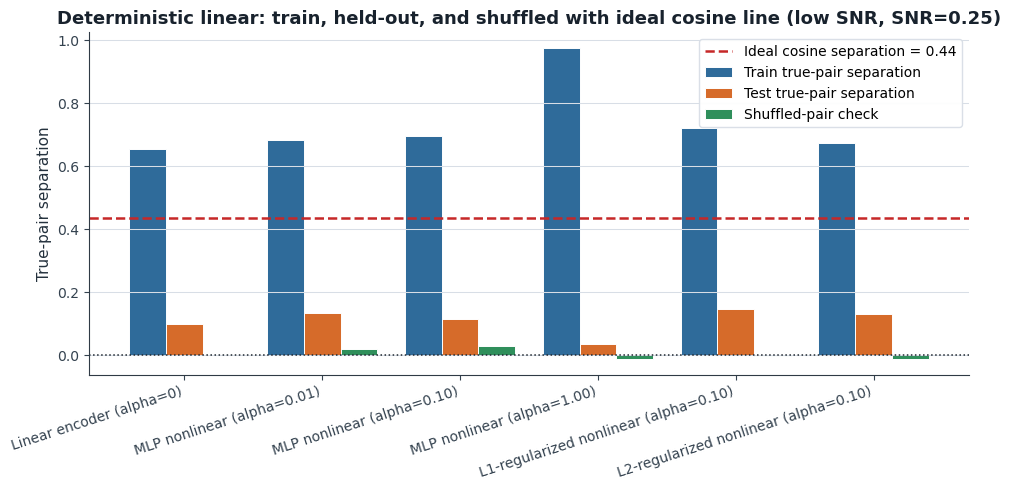

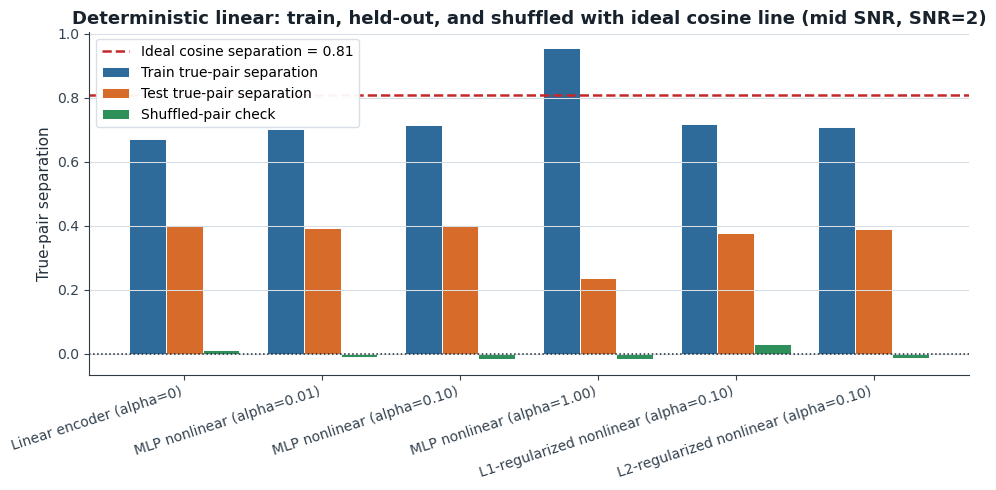

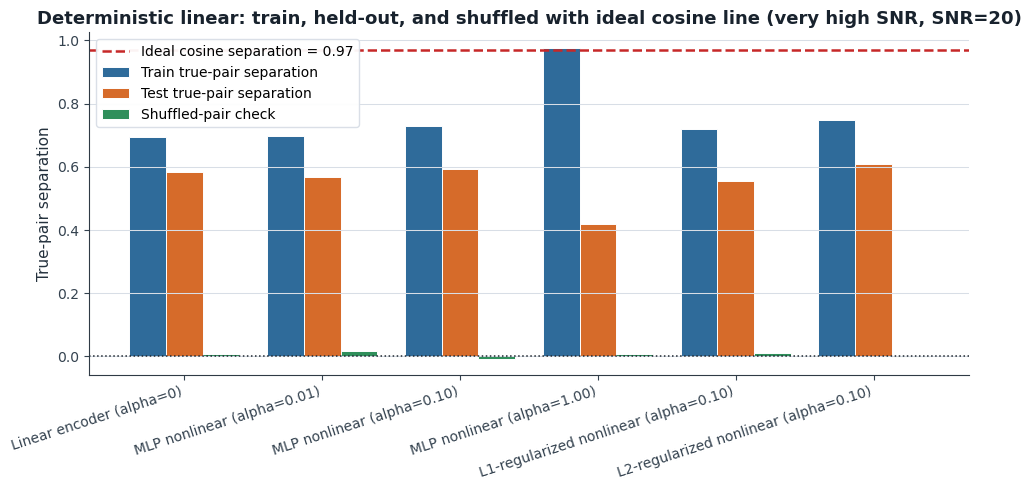

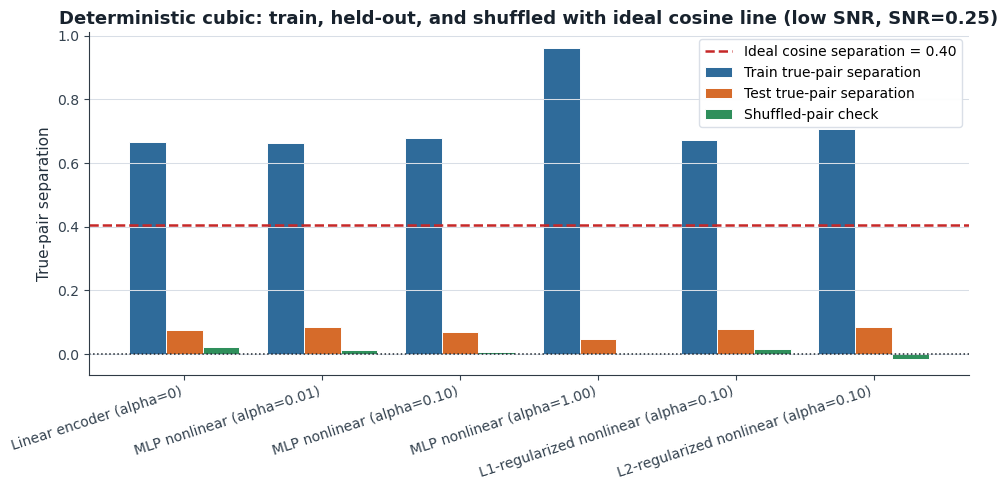

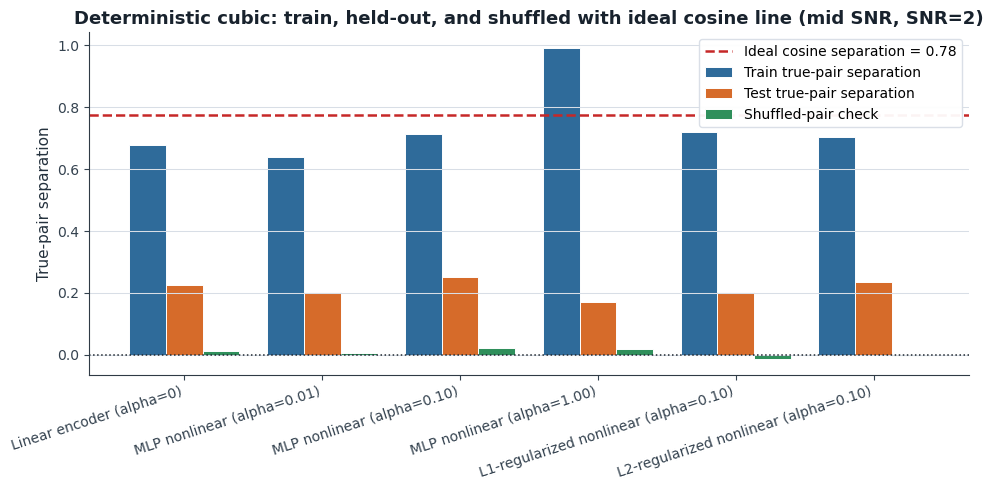

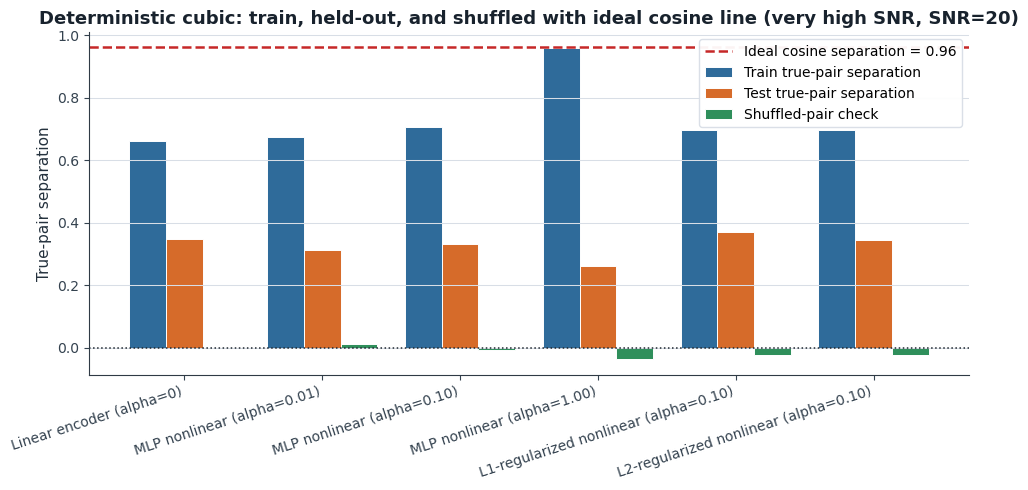

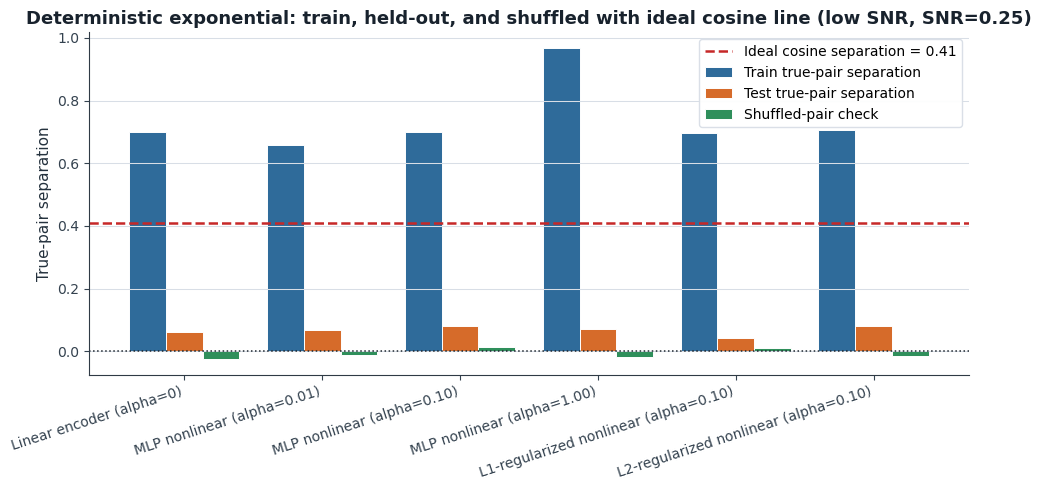

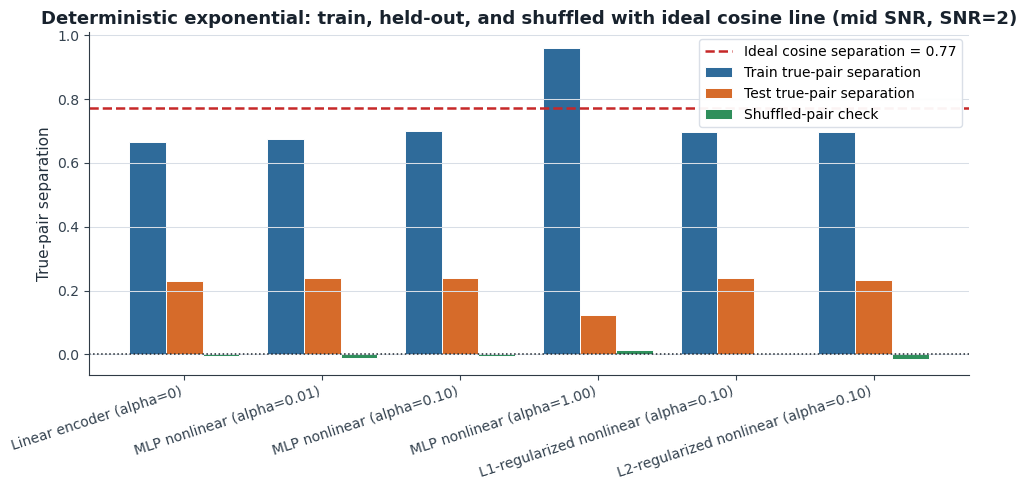

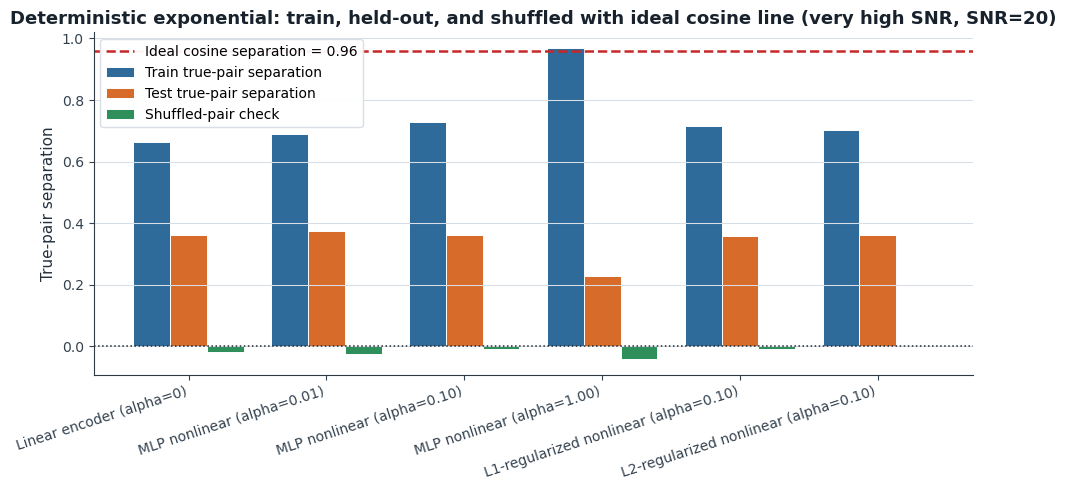

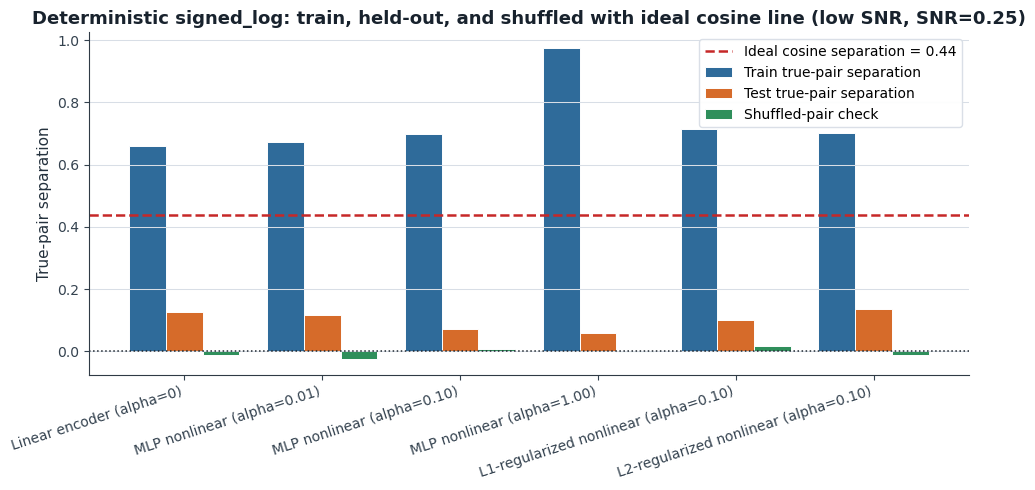

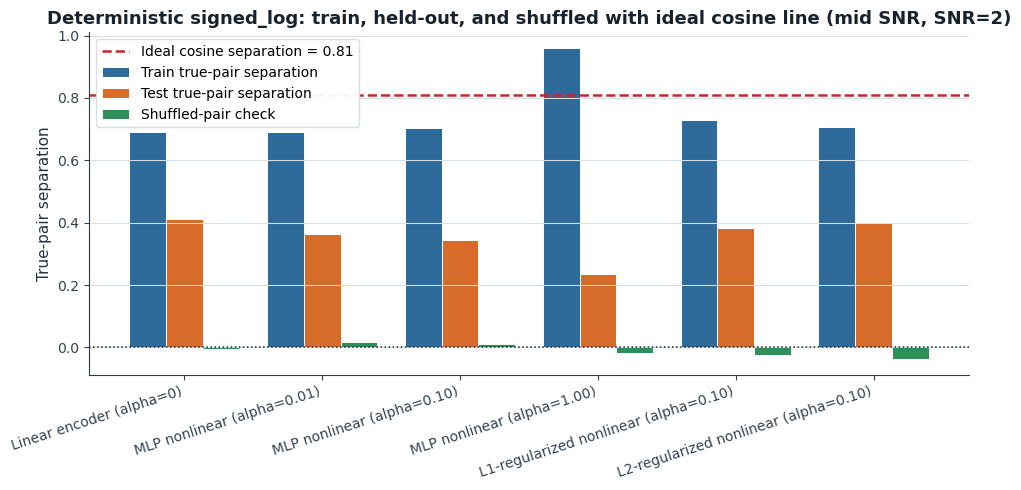

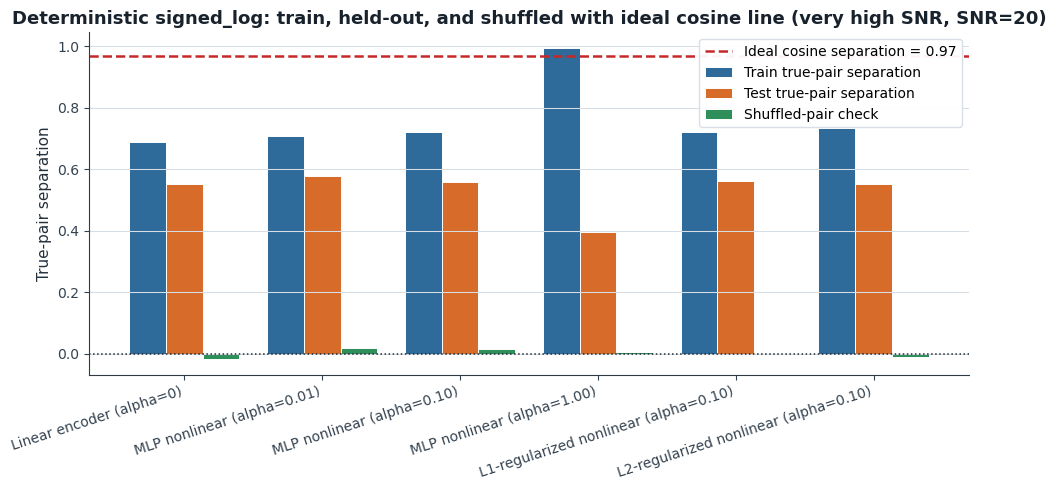

In [18]:
for relationship in deterministic_relationships:
    setting_name = f"Deterministic {relationship}"

    for target_snr in deterministic_bar_snr_values:
        level_label = snr_label(target_snr)
        subset = deterministic_results[
            (deterministic_results["relationship"] == relationship)
            & (deterministic_results["target_snr"] == target_snr)
        ].copy()

        reference_y = float(subset["ideal_cosine_separation"].iloc[0])

        plot_metric_by_config(
            subset,
            setting=setting_name,
            metrics=[
                "train_pair_separation",
                "test_pair_separation",
                "shuffled_pair_separation",
            ],
            title=(
                f"{setting_name}: train, held-out, and shuffled with ideal cosine line "
                f"({level_label}, SNR={target_snr:g})"
            ),
            ylabel="True-pair separation",
            save_dir=PLOT_DIR,
            reference_line_y=reference_y,
            reference_line_label=f"Ideal cosine separation = {reference_y:.2f}",
        )


## 8. Test separation versus SNR with ideal cosine curve

This keeps the main deterministic sweep: held-out/test true-pair separation versus target SNR. The red dashed curve is the empirical ideal cosine-separation reference for each generated dataset.

Each sweep is saved twice: one version uses `ax.set_xscale("log")` so the x-axis ticks appear as powers of 10, and one version keeps the x-axis linear. The SNR values themselves are not log-transformed or changed. The representative bar plots above are categorical model comparisons, so they do not have a continuous SNR axis to log-scale.


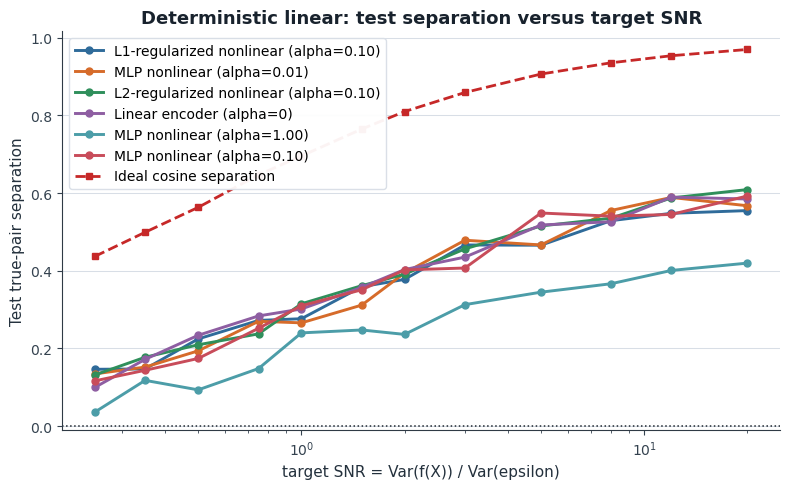

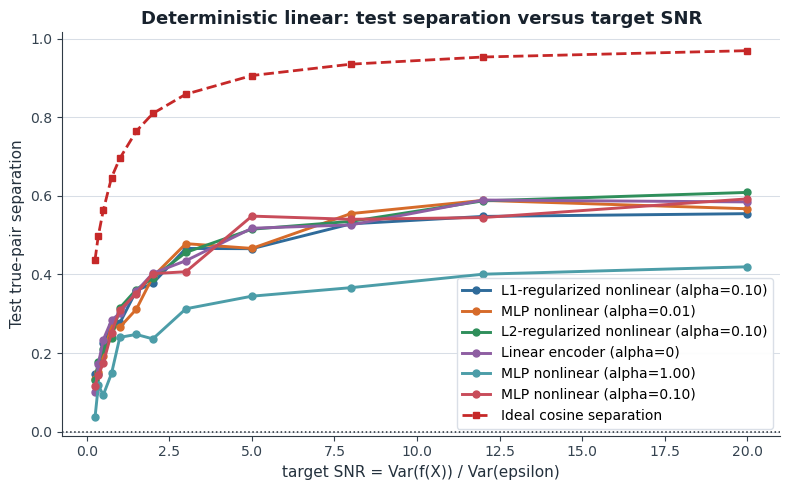

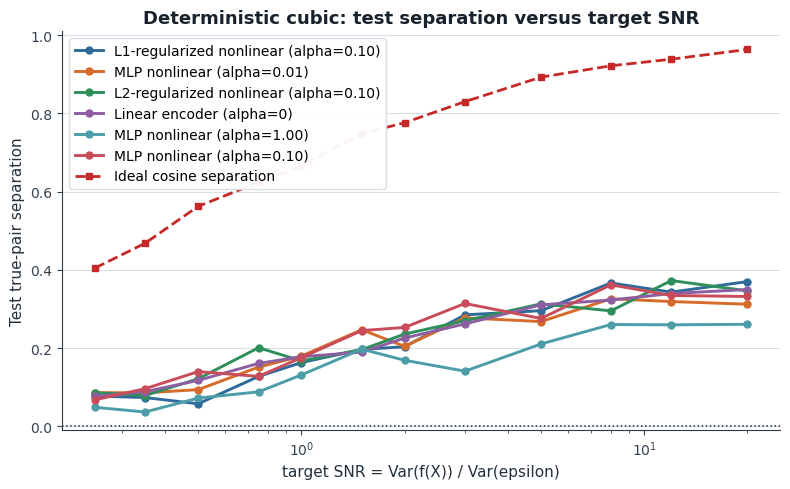

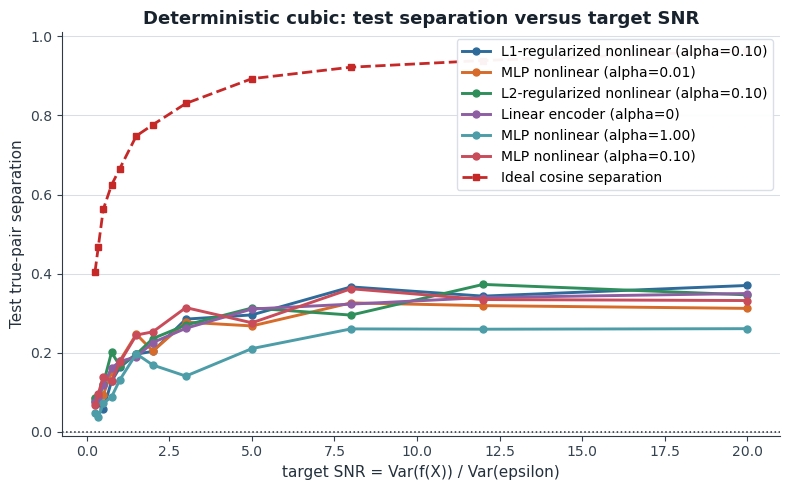

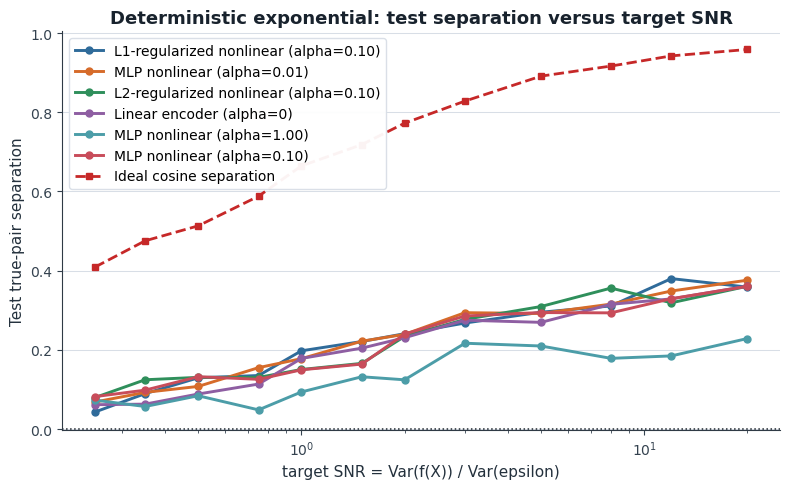

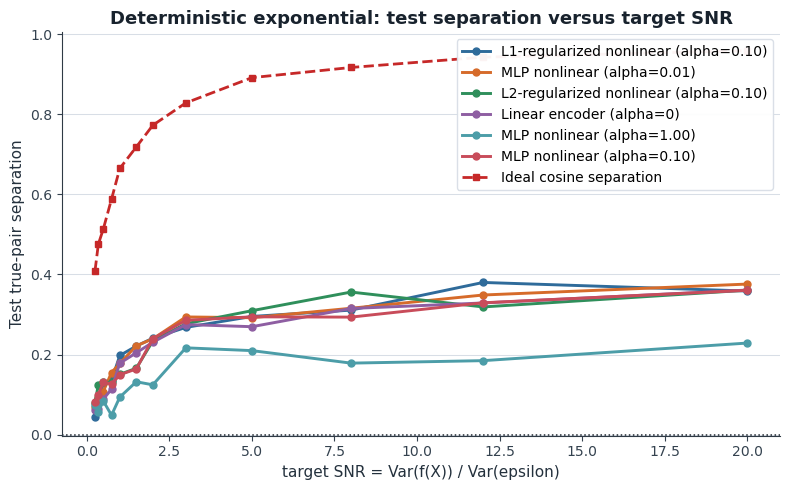

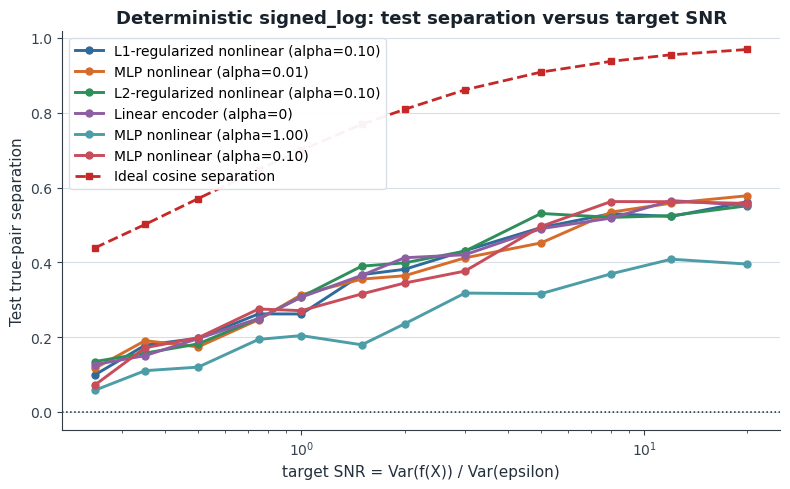

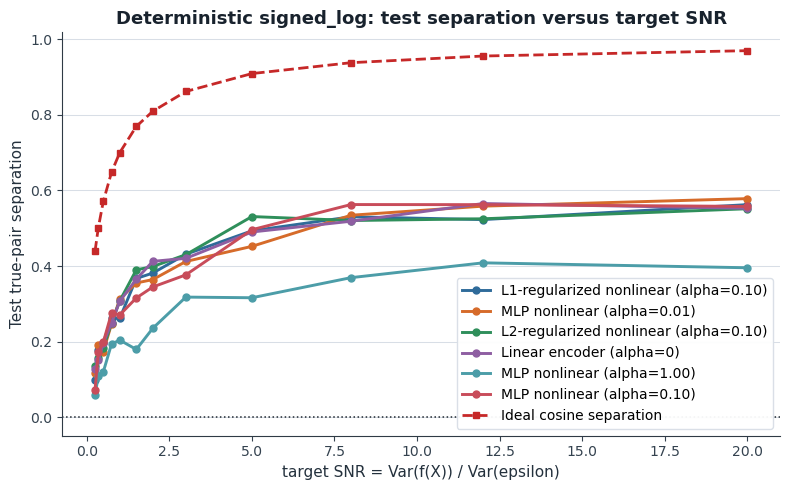

In [19]:
def plot_deterministic_cosine_reference_sweep(
    results,
    reference,
    relationship,
    use_log_snr_axis: bool,
):
    plot_data = results[results["relationship"] == relationship].copy()
    ref_data = reference[reference["relationship"] == relationship].copy()

    averaged = (
        plot_data.groupby(["config", "target_snr"], as_index=False)["test_pair_separation"]
        .mean()
        .sort_values("target_snr")
    )

    filename_axis = "log-x-axis" if use_log_snr_axis else "linear-x-axis"

    fig, ax = plt.subplots(figsize=(8, 5))

    for index, (config_name, group) in enumerate(averaged.groupby("config", sort=False)):
        ax.plot(
            group["target_snr"],
            group["test_pair_separation"],
            marker="o",
            markersize=5,
            linewidth=2.1,
            label=config_name,
            color=REPORT_PALETTE[index % len(REPORT_PALETTE)],
        )

    ax.plot(
        ref_data["target_snr"],
        ref_data["ideal_cosine_separation"],
        linestyle="--",
        marker="s",
        markersize=5,
        linewidth=2.0,
        label="Ideal cosine separation",
        color=REFERENCE_LINE_COLOR,
    )

    ax.axhline(0, linestyle=":", color="#202830", linewidth=1.1)
    if use_log_snr_axis:
        ax.set_xscale("log")
    ax.set_title(
        f"Deterministic {relationship}: test separation versus target SNR"
    )
    ax.set_xlabel("target SNR = Var(f(X)) / Var(epsilon)")
    ax.set_ylabel("Test true-pair separation")
    ax.grid(axis="y")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend()

    output_path = PLOT_DIR / (
        f"deterministic-{relationship}-test-separation-versus-target-snr-"
        f"{filename_axis}.png"
    )
    fig.tight_layout()
    fig.savefig(output_path, dpi=240, facecolor="white", bbox_inches="tight")
    plt.show()
    return output_path


for relationship in deterministic_relationships:
    for use_log_snr_axis in [True, False]:
        plot_deterministic_cosine_reference_sweep(
            deterministic_results,
            ideal_reference,
            relationship=relationship,
            use_log_snr_axis=use_log_snr_axis,
        )


## 9. Overfitting diagnostics versus SNR

For this diagnostic, the suspicious direction is `train - ideal`, not `ideal - train`.

```text
excess over ideal = max(train separation - ideal cosine separation, 0)
train-test gap    = max(train separation - test separation, 0)
```

`ideal - train` would measure remaining room below the ideal reference. It would be useful as a performance-gap measure, but it would not measure overfitting. For overfitting, the model is suspicious when training separation is too high relative to either the ideal reference or the held-out score.

The first plot asks whether the training score exceeds the ideal clean/noisy cosine reference. The second asks whether the training score fails to generalize to held-out data. A model is most suspicious when both are high. Each overfitting sweep is saved once with a log-scaled x-axis and once with a linear x-axis; the plotted SNR values are not transformed.


,Dataset,Deterministic relation,SNR level,Target SNR,Model,Train true-pair separation,Test true-pair separation,ideal_cosine_separation,excess_train_over_ideal,train_test_gap
0,Deterministic linear,linear,low SNR,0.25,Linear encoder (alpha=0),0.6537,0.0997,0.4370,0.2167,0.5540
1,Deterministic linear,linear,low SNR,0.25,MLP nonlinear (alpha=0.01),0.6829,0.1343,0.4370,0.2459,0.5486
2,Deterministic linear,linear,low SNR,0.25,MLP nonlinear (alpha=0.10),0.6974,0.1163,0.4370,0.2604,0.5810
3,Deterministic linear,linear,low SNR,0.25,MLP nonlinear (alpha=1.00),0.9752,0.0361,0.4370,0.5382,0.9391
4,Deterministic linear,linear,low SNR,0.25,L1-regularized nonlinear (alpha=0.10),0.7209,0.1461,0.4370,0.2839,0.5749
...,...,...,...,...,...,...,...,...,...,...
283,Deterministic signed_log,signed_log,very high SNR,20.00,MLP nonlinear (alpha=0.01),0.7070,0.5782,0.9692,0.0000,0.1288
284,Deterministic signed_log,signed_log,very high SNR,20.00,MLP nonlinear (alpha=0.10),0.7221,0.5576,0.9692,0.0000,0.1645
285,Deterministic signed_log,signed_log,very high SNR,20.00,MLP nonlinear (alpha=1.00),0.9941,0.3954,0.9692,0.0248,0.5986
286,Deterministic signed_log,signed_log,very high SNR,20.00,L1-regularized nonlinear (alpha=0.10),0.7217,0.5623,0.9692,0.0000,0.1594


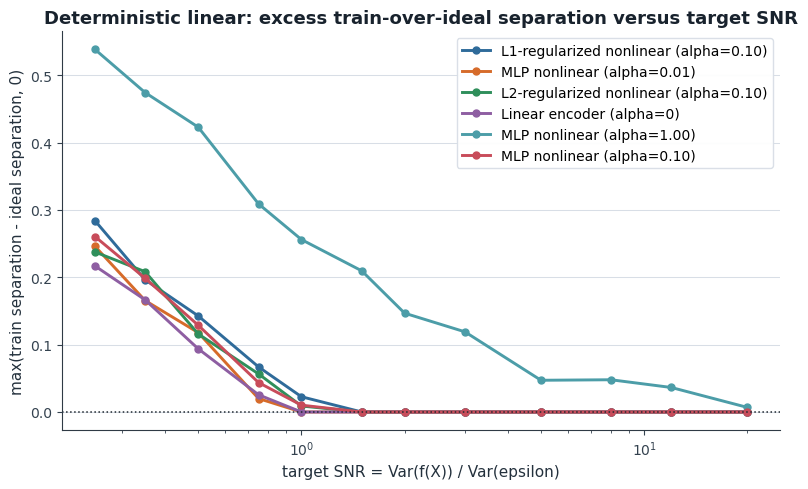

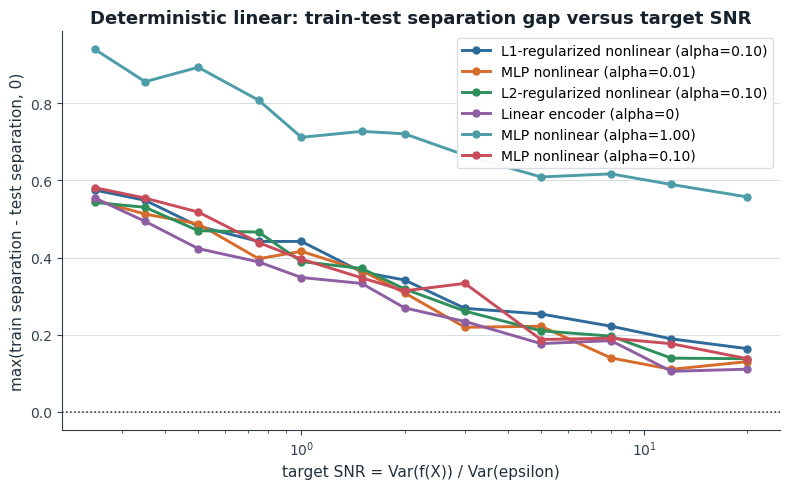

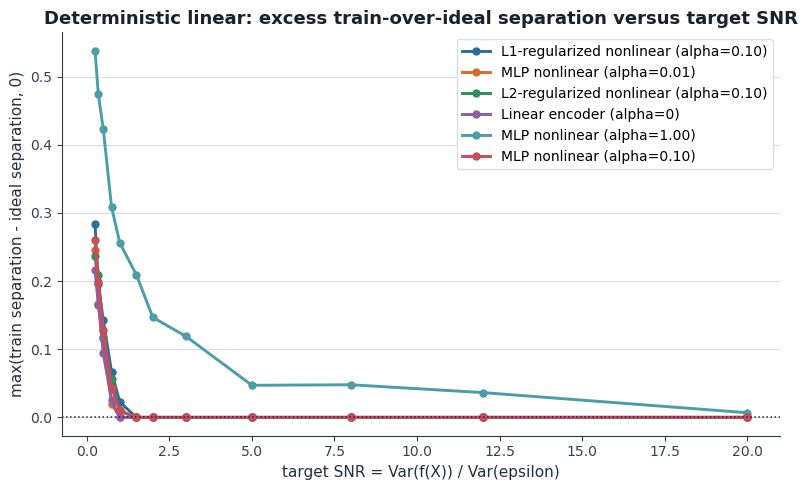

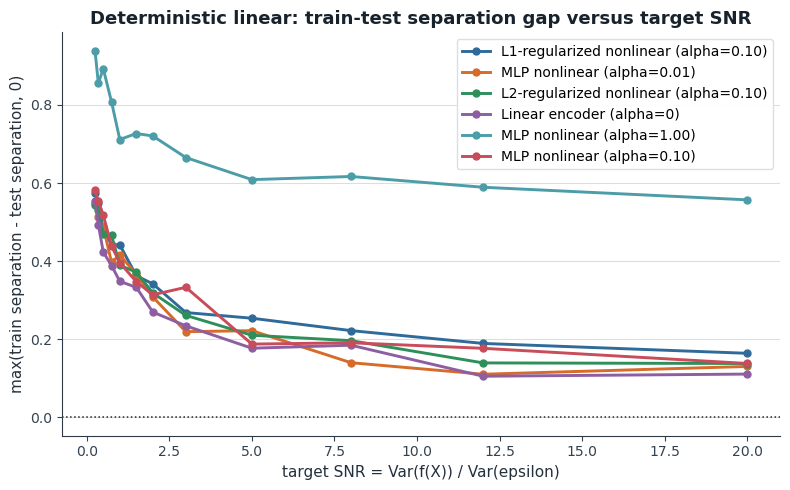

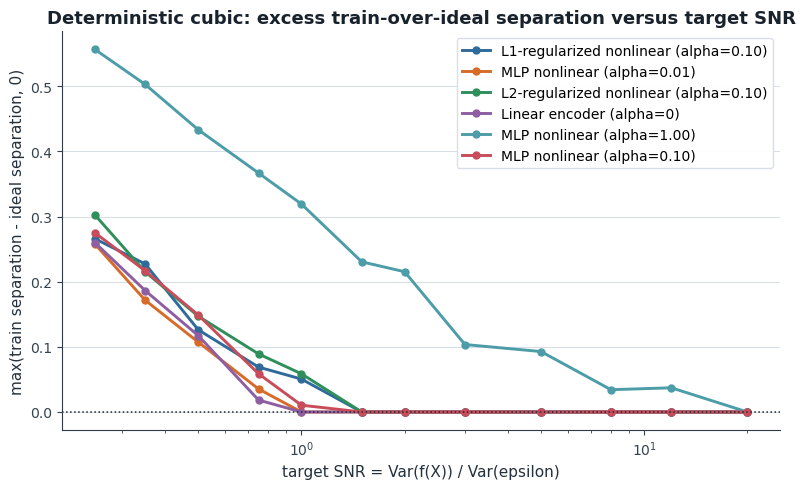

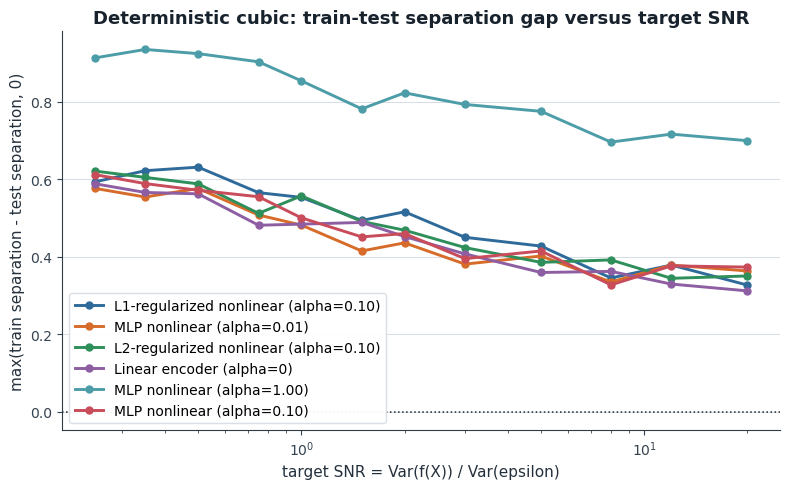

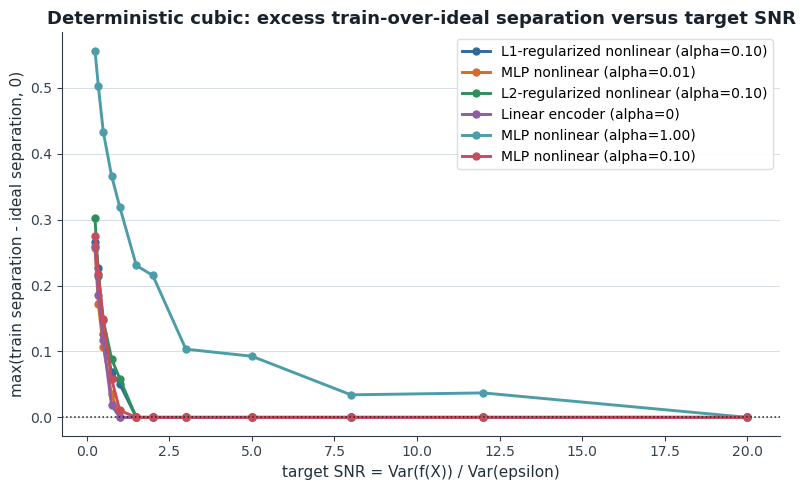

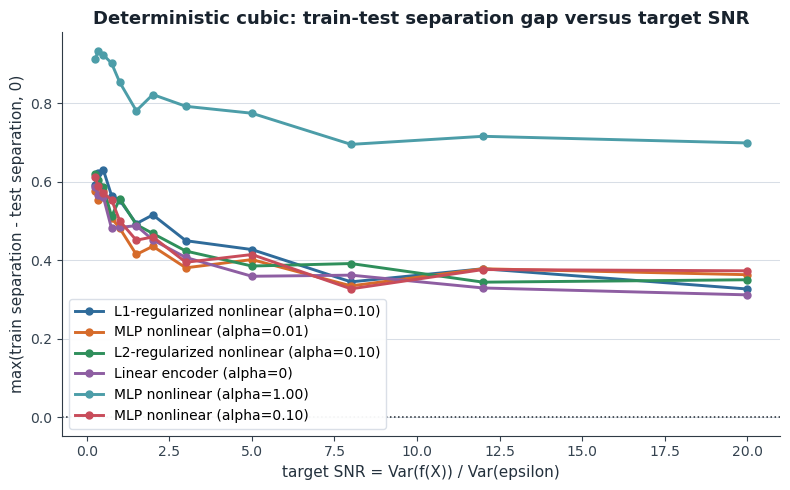

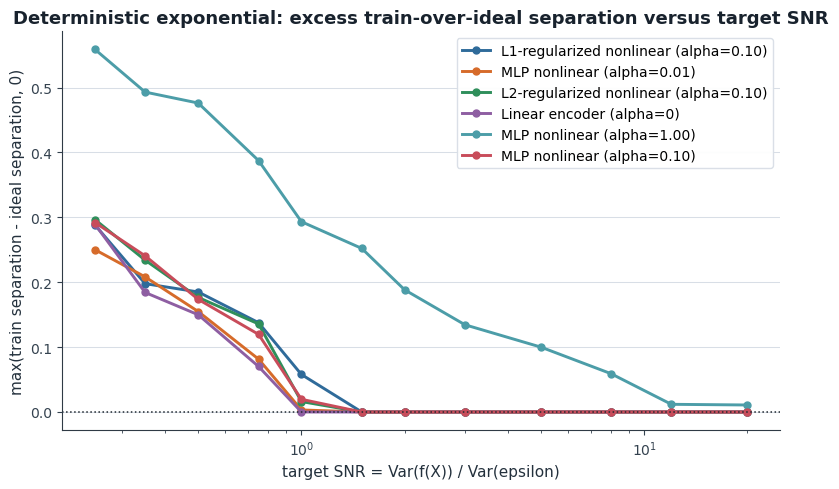

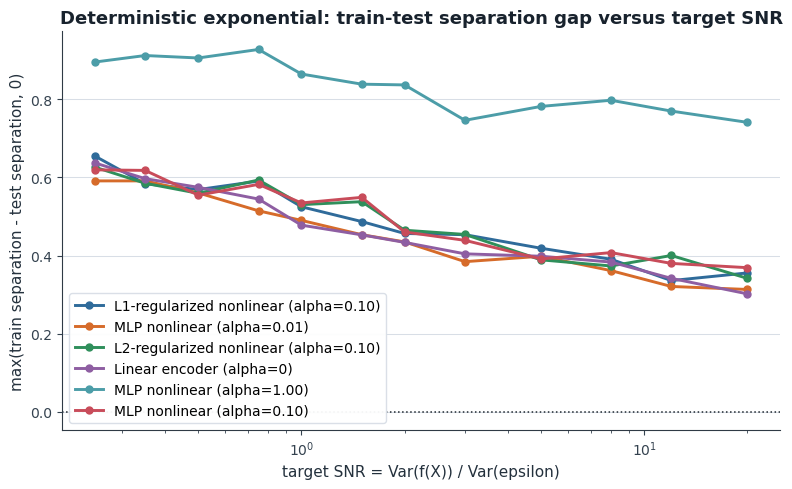

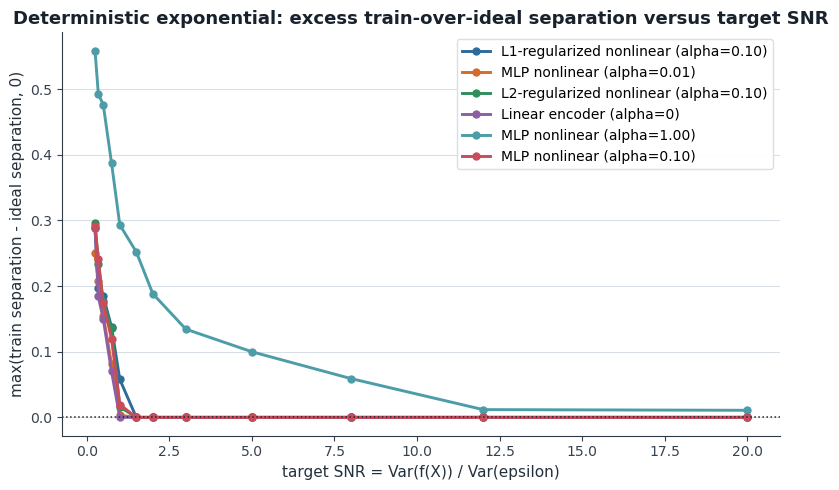

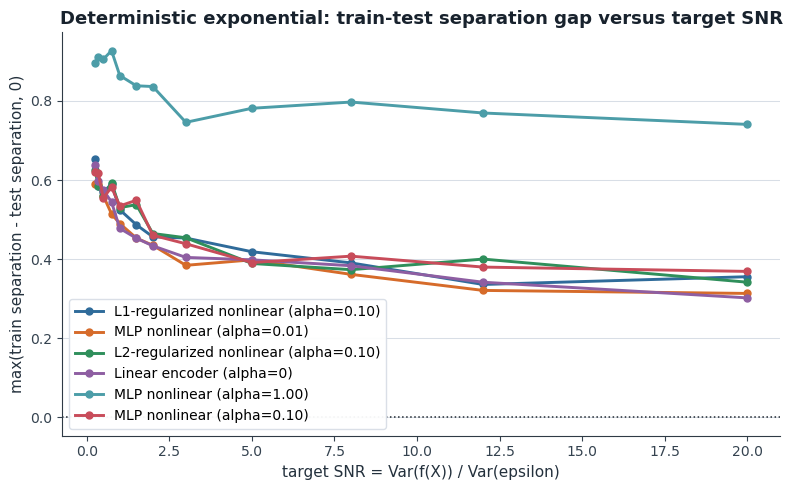

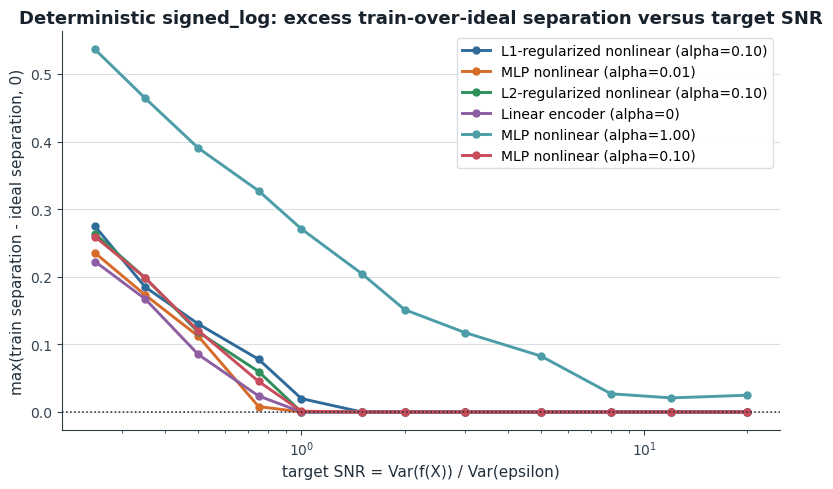

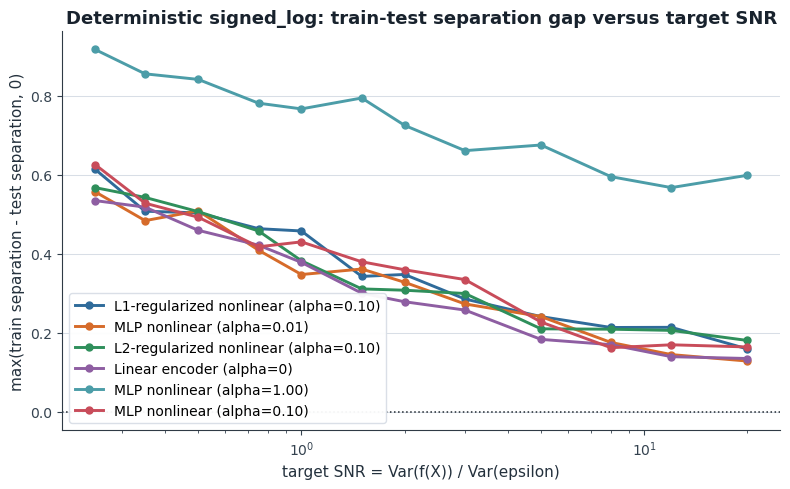

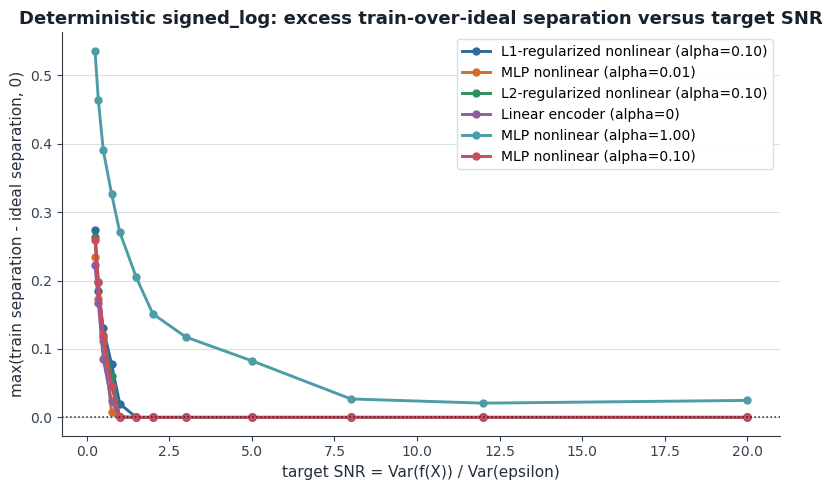

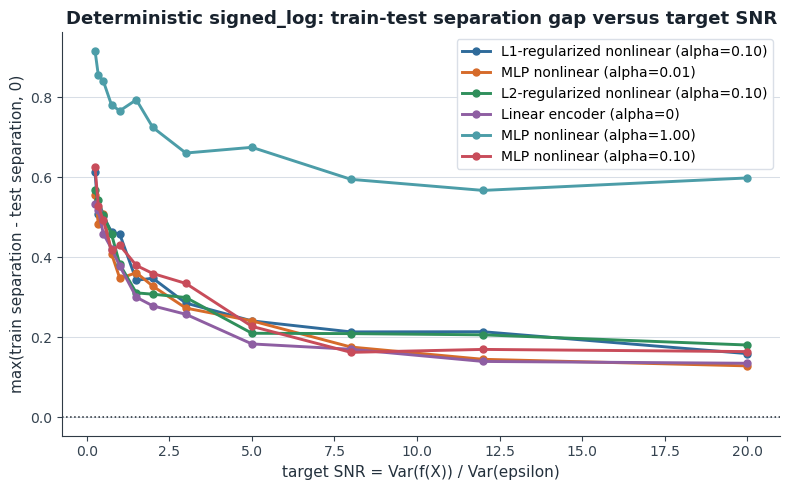

In [20]:
overfit_results = deterministic_results.copy()
overfit_results["excess_train_over_ideal"] = np.maximum(
    overfit_results["train_pair_separation"]
    - overfit_results["ideal_cosine_separation"],
    0.0,
)
overfit_results["train_test_gap"] = np.maximum(
    overfit_results["train_pair_separation"]
    - overfit_results["test_pair_separation"],
    0.0,
)

display(
    friendly_results_table(
        overfit_results[
            [
                "setting",
                "relationship",
                "snr_level",
                "target_snr",
                "config",
                "train_pair_separation",
                "test_pair_separation",
                "ideal_cosine_separation",
                "excess_train_over_ideal",
                "train_test_gap",
            ]
        ].round(4)
    )
)


def plot_overfitting_sweep(
    results,
    relationship,
    metric,
    ylabel,
    title_suffix,
    filename_suffix,
    use_log_snr_axis: bool,
):
    plot_data = results[results["relationship"] == relationship].copy()
    averaged = (
        plot_data.groupby(["config", "target_snr"], as_index=False)[metric]
        .mean()
        .sort_values("target_snr")
    )

    filename_axis = "log-x-axis" if use_log_snr_axis else "linear-x-axis"

    fig, ax = plt.subplots(figsize=(8, 5))

    for index, (config_name, group) in enumerate(averaged.groupby("config", sort=False)):
        ax.plot(
            group["target_snr"],
            group[metric],
            marker="o",
            markersize=5,
            linewidth=2.1,
            label=config_name,
            color=REPORT_PALETTE[index % len(REPORT_PALETTE)],
        )

    ax.axhline(0, linestyle=":", color="#202830", linewidth=1.1)
    if use_log_snr_axis:
        ax.set_xscale("log")
    ax.set_title(
        f"Deterministic {relationship}: {title_suffix} versus target SNR"
    )
    ax.set_xlabel("target SNR = Var(f(X)) / Var(epsilon)")
    ax.set_ylabel(ylabel)
    ax.grid(axis="y")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend()

    output_path = PLOT_DIR / (
        f"deterministic-{relationship}-{filename_suffix}-versus-target-snr-"
        f"{filename_axis}.png"
    )
    fig.tight_layout()
    fig.savefig(output_path, dpi=240, facecolor="white", bbox_inches="tight")
    plt.show()
    return output_path


for relationship in deterministic_relationships:
    for use_log_snr_axis in [True, False]:
        plot_overfitting_sweep(
            overfit_results,
            relationship=relationship,
            metric="excess_train_over_ideal",
            ylabel="max(train separation - ideal separation, 0)",
            title_suffix="excess train-over-ideal separation",
            filename_suffix="excess-train-over-ideal-separation",
            use_log_snr_axis=use_log_snr_axis,
        )

        plot_overfitting_sweep(
            overfit_results,
            relationship=relationship,
            metric="train_test_gap",
            ylabel="max(train separation - test separation, 0)",
            title_suffix="train-test separation gap",
            filename_suffix="train-test-separation-gap",
            use_log_snr_axis=use_log_snr_axis,
        )


## 10. Interpretation

The converted line answers a different question from the original PVE line:

```text
How large would the separation be if we compared the clean deterministic target f(X)
to the noisy observed Y using the same cosine-separation metric?
```

That makes it valid to draw on the cosine-separation plots. It is still an **ideal full-target reference**, not a hard ceiling for the 4D learned encoders. The learned models compress 128 input dimensions into 4 embedding dimensions, so they can sit well below the ideal line even when they are learning useful pair alignment.

For the overfitting plots, `excess_train_over_ideal` is a stricter memorization-style warning, while `train_test_gap` is the usual generalization warning. Both are clipped at zero so the plots show only suspicious excess, not ordinary underperformance.
